In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("linear_regression_3.csv")  # Replace with actual file path

In [3]:
# Normalize the data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [4]:
# Compute IQR
Q1 = df_scaled.quantile(0.25)
Q3 = df_scaled.quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = ((df_scaled < lower_bound) | (df_scaled > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df[~outliers]

In [5]:
print(f"Original rows: {df.shape[0]}, Cleaned rows: {df_cleaned.shape[0]}")

Original rows: 1000, Cleaned rows: 910


In [6]:
# Split data into features and target
X_cleaned = df_cleaned.drop(columns=["y"])
y_cleaned = df_cleaned["y"]

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

In [8]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Make predictions
y_pred = model.predict(X_test)

In [10]:
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [11]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Intercept: {model.intercept_:.2f}")

Mean Squared Error: 741.36
R² Score: 0.6674
Intercept: 0.04


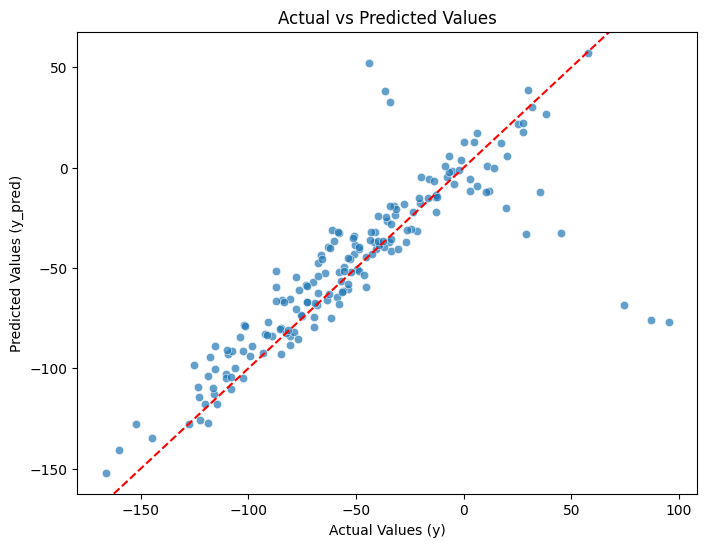

In [12]:
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Values (y)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs Predicted Values")
plt.axline([0, 0], slope=1, color="red", linestyle="--")  # Reference line
plt.show()

In [13]:
# Compute MAD-based outlier removal
median = df_scaled.median()
mad = np.median(np.abs(df_scaled - median), axis=0)
threshold = 3  # Typically 3 for outlier detection
modified_z_score = 0.6745 * (df_scaled - median) / mad

# Identify outliers
outliers = (np.abs(modified_z_score) > threshold).any(axis=1)

# Remove outliers
df_cleaned = df[~outliers]

In [14]:
print(f"Original rows: {df.shape[0]}, Cleaned rows: {df_cleaned.shape[0]}")

Original rows: 1000, Cleaned rows: 938


In [15]:
# Split data into features and target
X_cleaned = df_cleaned.drop(columns=["y"])
y_cleaned = df_cleaned["y"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

In [16]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


In [17]:
# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Intercept: {model.intercept_:.2f}")

Mean Squared Error: 763.08
R² Score: 0.6561
Intercept: -10.16


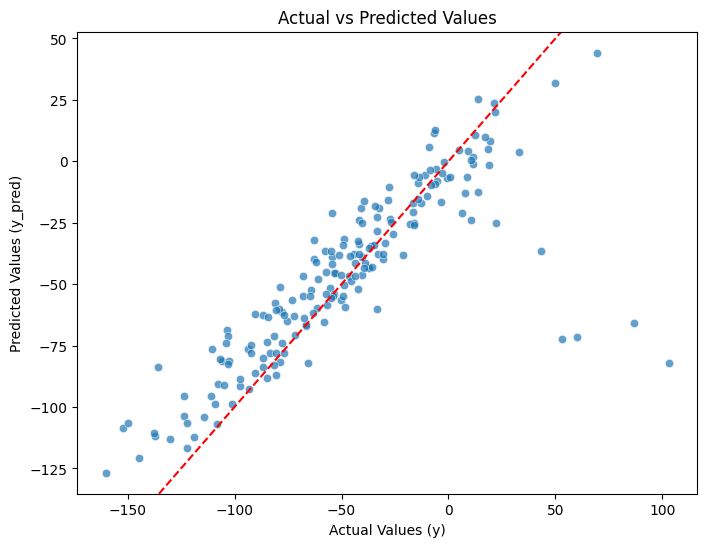

In [18]:
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Values (y)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs Predicted Values")
plt.axline([0, 0], slope=1, color="red", linestyle="--")  # Reference line
plt.show()